In [1]:
import pandas as pd

df = pd.read_csv("../data/train-metadata.csv")
display(df.head())
display(len(df))
display(df["target"].value_counts())
display(df["target"].value_counts(normalize=True))

,Unnamed: 0,isic_id,patient_id,target
0,0,ISIC_0028498,HAM_0000000,0.0
1,1,ISIC_0027859,HAM_0000001,0.0
2,2,ISIC_0034246,HAM_0000002,1.0
3,3,ISIC_0027886,HAM_0000003,0.0
4,4,ISIC_0024645,HAM_0000004,0.0


8982

target
0.0    8197
1.0     785
Name: count, dtype: int64

target
0.0    0.912603
1.0    0.087397
Name: proportion, dtype: float64

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

image_dir = "../data/train-image"

display(len(os.listdir(image_dir)))

missing = []

for image_id in df["isic_id"]:
    path = os.path.join(image_dir, image_id + ".jpg")
    if not os.path.exists(path):
        missing.append(image_id)

display(len(missing))

7497

1486

In [3]:
# filtrar solo filas cuya imagen exista
df_clean = df[df["isic_id"].apply(
    lambda x: os.path.exists(os.path.join(image_dir, x + ".jpg"))
)]

print("Filas originales:", len(df))
print("Filas con imagen disponible:", len(df_clean))

display(len(df_clean))
display(len(os.listdir(image_dir)))

df_clean.to_csv("../data/metadata_clean.csv", index=False)
df = df_clean


Filas originales: 8982
Filas con imagen disponible: 7496


7496

7497

In [4]:
display(df["target"].value_counts())
df["target"].value_counts(normalize=True)

target
0.0    6834
1.0     662
Name: count, dtype: int64

target
0.0    0.911686
1.0    0.088314
Name: proportion, dtype: float64

In [5]:
df["patient_id"].nunique()

7496

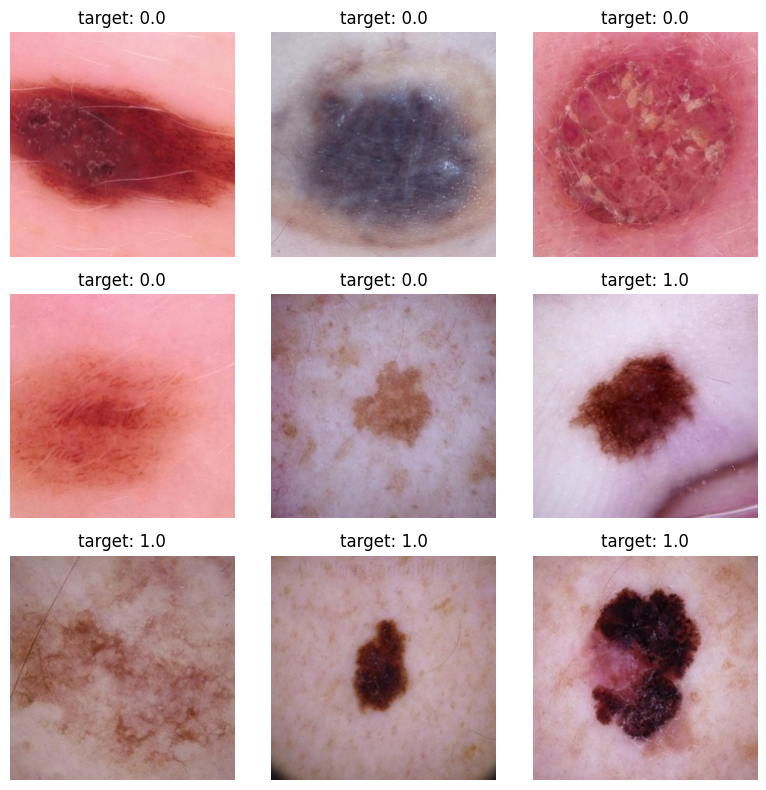

In [6]:
# seleccionar algunas muestras aleatorias de ambos tipos
benign = df[df["target"] == 0].sample(5)
malignant = df[df["target"] == 1].sample(4)

sample = pd.concat([benign, malignant])

plt.figure(figsize=(8,8))

for i, (_, row) in enumerate(sample.iterrows()):
    
    image_path = os.path.join(image_dir, row["isic_id"] + ".jpg")
    
    img = Image.open(image_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"target: {row['target']}")
    plt.axis("off")

plt.tight_layout()

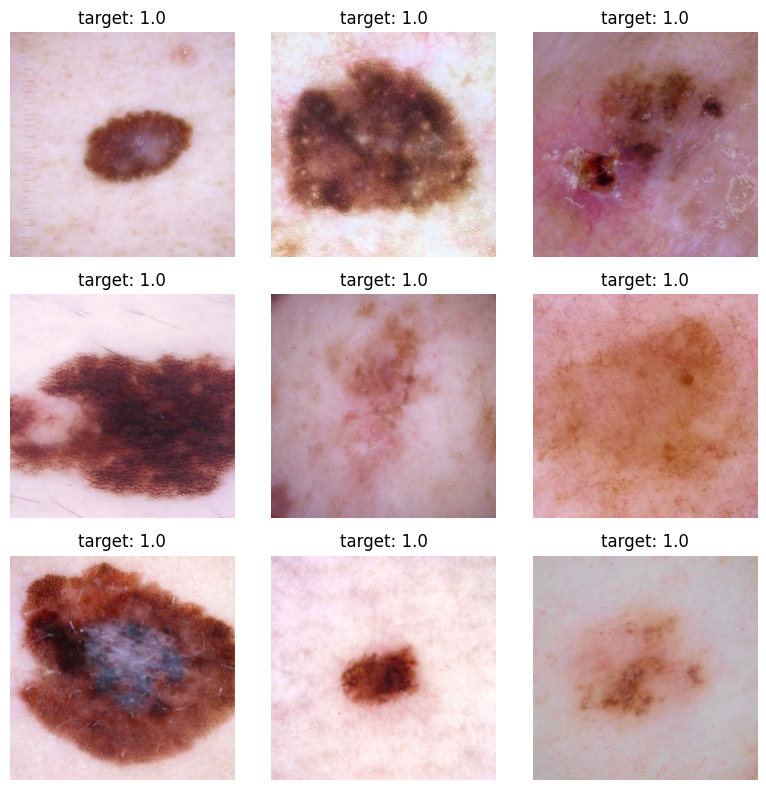

In [7]:
only_malignant = df[df["target"] == 1].sample(9)

plt.figure(figsize=(8,8))

for i, (_, row) in enumerate(only_malignant.iterrows()):
    
    image_path = os.path.join(image_dir, row["isic_id"] + ".jpg")
    
    img = Image.open(image_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"target: {row['target']}")
    plt.axis("off")

plt.tight_layout()

In [8]:
from PIL import UnidentifiedImageError

sizes = []
valid_ext = (".jpg", ".jpeg", ".png")

for img_name in os.listdir(image_dir):
    if not img_name.lower().endswith(valid_ext):
        continue
    path = os.path.join(image_dir, img_name)
    try:
        with Image.open(path) as img:
            sizes.append(img.size)
    except UnidentifiedImageError:
        pass 

pd.Series(sizes).value_counts().head()


(224, 224)    7496
Name: count, dtype: int64